# Logistic Regression Project Exercise

**GOAL: Create a Classification Model that can predict whether or not a person has presence of heart disease based on physical features of that person (age,sex, cholesterol, etc...)**

**Complete the TASKs written in bold below.**

## Imports

**TASK: Run the cell below to import the necessary libraries.**

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Data

This database contains 14 physical attributes based on physical testing of a patient. Blood samples are taken and the patient also conducts a brief exercise test. The "goal" field refers to the presence of heart disease in the patient. It is integer (0 for no presence, 1 for presence). In general, to confirm 100% if a patient has heart disease can be quite an invasive process, so if we can create a model that accurately predicts the likelihood of heart disease, we can help avoid expensive and invasive procedures.

Content

Attribute Information:

* age
* sex
* chest pain type (4 values)
* resting blood pressure
* serum cholestoral in mg/dl
* fasting blood sugar > 120 mg/dl
* resting electrocardiographic results (values 0,1,2)
* maximum heart rate achieved
* exercise induced angina
* oldpeak = ST depression induced by exercise relative to rest
* the slope of the peak exercise ST segment
* number of major vessels (0-3) colored by flourosopy
* thal: 3 = normal; 6 = fixed defect; 7 = reversable defect
* target:0 for no presence of heart disease, 1 for presence of heart disease

Original Source: https://archive.ics.uci.edu/ml/datasets/Heart+Disease


**TASK: Run the cell below to read in the data.**

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0
sex,303.0,0.683168,0.466011,0.0,0.0,1.0,1.0,1.0
cp,303.0,0.966997,1.032052,0.0,0.0,1.0,2.0,3.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.528053,0.525860,0.0,0.0,1.0,1.0,2.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [5]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

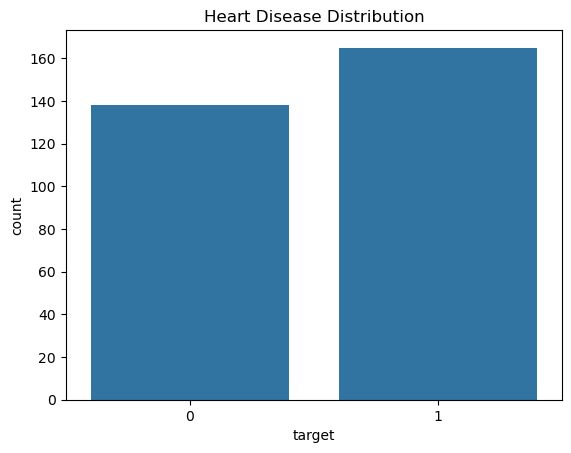

In [6]:
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.show()

# Machine Learning

## Train | Test Split and Scaling

**TASK: Separate the features from the labels into 2 objects, X and y.**

In [7]:
X = df.drop('target', axis=1)
y = df['target']

In [8]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [9]:
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

**TASK: Perform a train test split on the data, with the test size of 10% and a random_state of 101.**

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [12]:
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 272 samples
Test set: 31 samples


In [13]:
scaler = StandardScaler()

In [14]:
# fit_transform on train (learns mean/std), transform only on test (avoids data leakage)
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [15]:
scaled_X_train[:5]

array([[ 1.04970247,  0.69737995,  1.97993226, -1.23533257, -0.6689593 ,
        -0.42732739, -0.99577247, -0.26215945,  1.47064295,  0.72762654,
        -0.67167968, -0.71422572, -0.4842146 ],
       [ 0.61644136,  0.69737995, -0.94692412, -0.83741797, -0.30815971,
         2.34012617,  0.89828426,  0.4395121 ,  1.47064295,  0.37070243,
         0.9451068 ,  1.23823052,  1.14178999],
       [-0.68334197,  0.69737995,  0.02869467, -1.23533257, -0.32714917,
        -0.42732739,  0.89828426,  0.79034787, -0.6799747 ,  0.01377832,
        -2.28846615, -0.71422572,  1.14178999],
       [-0.25008086, -1.43393855,  1.00431346,  0.24263595, -0.95380109,
        -0.42732739, -0.99577247,  0.83420234, -0.6799747 , -0.78930092,
        -0.67167968, -0.71422572, -0.4842146 ],
       [-0.89997253, -1.43393855, -0.94692412,  0.35632584, -0.06129683,
        -0.42732739, -0.99577247,  0.08867632,  1.47064295, -0.87853195,
        -0.67167968, -0.71422572, -0.4842146 ]])

In [16]:
scaled_X_test[:5]

array([[ 0.07486497,  0.69737995, -0.94692412,  0.47001573, -0.55502259,
        -0.42732739,  0.89828426, -1.70935702,  1.47064295,  4.11840557,
        -2.28846615, -0.71422572,  1.14178999],
       [-0.25008086,  0.69737995,  1.00431346,  2.28905391, -0.89683273,
         2.34012617,  0.89828426,  0.52722104, -0.6799747 , -0.43237682,
         0.9451068 , -0.71422572,  1.14178999],
       [ 0.3998108 , -1.43393855, -0.94692412, -1.803782  ,  0.03365043,
        -0.42732739, -0.99577247, -1.22695783, -0.6799747 ,  0.01377832,
        -0.67167968, -0.71422572, -0.4842146 ],
       [-1.65817947, -1.43393855,  1.00431346,  0.35632584, -0.49805423,
        -0.42732739,  0.89828426,  0.08867632, -0.6799747 , -0.87853195,
        -0.67167968, -0.71422572, -0.4842146 ],
       [ 0.61644136,  0.69737995, -0.94692412, -0.38265842,  0.22354495,
        -0.42732739, -0.99577247, -0.39372287,  1.47064295,  1.61993681,
        -0.67167968,  0.2620024 ,  1.14178999]])

**TASK: Create a StandardScaler object and normalize the X train and test set feature data. Make sure you only fit to the training data to avoid data leakage (data knowledge leaking from the test set).**

## Logistic Regression Model

**TASK: Create a Logistic Regression model

In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
log_model = LogisticRegression()

In [19]:
log_model.fit(scaled_X_train, y_train)

LogisticRegression()

In [20]:
y_pred = log_model.predict(scaled_X_test)

In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

In [22]:
accuracy_score(y_test, y_pred)

0.8387096774193549

### Coeffecients

**TASK: Report back the model's coefficients.**

In [23]:
log_model.coef_

array([[-0.07244537, -0.73459575,  0.89371356, -0.26249543, -0.21218597,
         0.04596441,  0.12036576,  0.43326353, -0.42823456, -0.52722504,
         0.38098131, -0.85080651, -0.57468743]])

In [24]:
coef_df = pd.DataFrame(log_model.coef_.flatten(), index=X.columns, columns=['Coefficient'])
coef_df.sort_values('Coefficient', ascending=False)

,Coefficient
cp,0.893714
thalach,0.433264
slope,0.380981
restecg,0.120366
fbs,0.045964
age,-0.072445
chol,-0.212186
trestbps,-0.262495
exang,-0.428235
oldpeak,-0.527225


In [25]:
log_model.intercept_

array([0.17681761])

## Model Performance Evaluation

**TASK: Let's now evaluate your model on the remaining 10% of the data, the test set.**

**TASK: Create the following evaluations:**
* Confusion Matrix Array
* Confusion Matrix Plot
* Classification Report

In [26]:
confusion_matrix(y_test, y_pred)

array([[12,  3],
       [ 2, 14]])

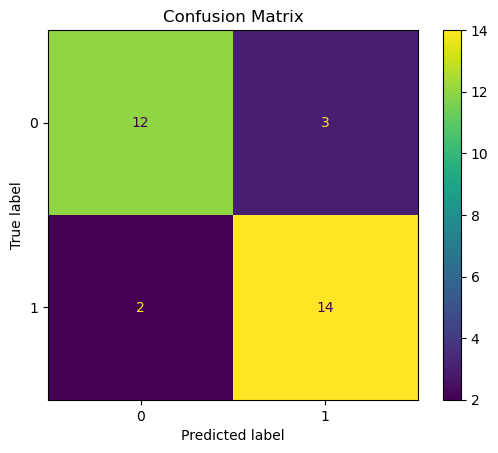

In [27]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Confusion Matrix')
plt.show()

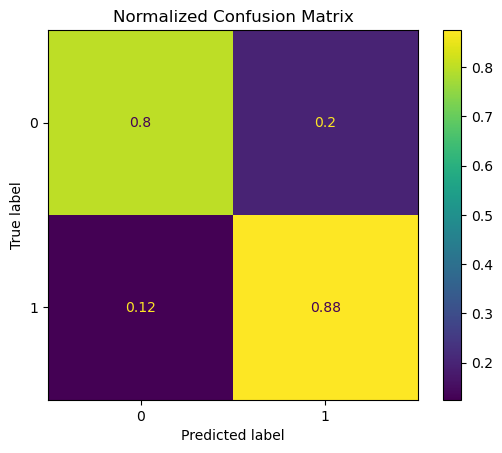

In [28]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true')
plt.title('Normalized Confusion Matrix')
plt.show()

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.80      0.83        15
           1       0.82      0.88      0.85        16

    accuracy                           0.84        31
   macro avg       0.84      0.84      0.84        31
weighted avg       0.84      0.84      0.84        31



### Performance Curves

**TASK: Create the ROC Curve.**

In [30]:
from sklearn.metrics import roc_curve, roc_auc_score

In [31]:
y_prob = log_model.predict_proba(scaled_X_test)[:,1]

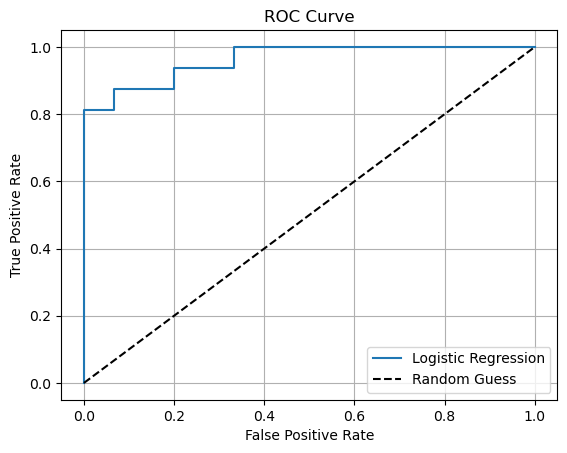

In [32]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

In [33]:
print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

AUC Score: 0.9625


**Final Task: A patient with the following features has come into the medical office:**

    age          48.0
    sex           0.0
    cp            2.0
    trestbps    130.0
    chol        275.0
    fbs           0.0
    restecg       1.0
    thalach     139.0
    exang         0.0
    oldpeak       0.2
    slope         2.0
    ca            0.0
    thal          2.0

**TASK: What does your model predict for this patient? Do they have heart disease? How "sure" is your model of this prediction?**

*For convience, we created an array of the features for the patient above*

In [34]:
patient = [[48, 0, 2, 130, 275, 0, 1, 139, 0, 0.2, 2, 0, 2]]

In [35]:
patient_scaled = scaler.transform(patient)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [36]:
log_model.predict(patient_scaled)

array([1])

In [37]:
log_model.predict_proba(patient_scaled)

array([[0.02036527, 0.97963473]])

In [38]:
proba = log_model.predict_proba(patient_scaled)[0]
pred = log_model.predict(patient_scaled)[0]
print(f"Prediction: {'Heart Disease' if pred == 1 else 'No Heart Disease'}")
print(f"Confidence: {proba[pred]*100:.1f}%")

Prediction: Heart Disease
Confidence: 98.0%
